In [1]:
# Set the config path here, need to restart the notebook after changing this
config_file = '../configs/events_example.yaml'

# Imports

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt

import spice
spice.load_config(config_file)
from spice import config, directories, data_loaders, plot
from spice.data_loaders import resolve_copynumber_file, load_final_events
from spice.segmentation import create_events_in_segmentation_full

CHROM_LENS = data_loaders.load_chrom_lengths()
CHROMS = list(CHROM_LENS.keys())
CENTROMERES = data_loaders.load_centromeres()

%load_ext autoreload
%autoreload 2
%matplotlib inline

# Load data and results
**Note** that you have to run `spice event_inference --config configs/events_example.yaml` before you can access the plotting.

In [3]:
chrom_segments = pd.read_csv('../data/example_data_split.tsv',
                            sep='\t', index_col=['sample_id', 'chrom', 'allele']).sort_index()
final_events_df = pd.read_csv('../results/example_run/final_events.tsv',
                            sep='\t', dtype={'cn': str, 'diff': str})

# Plot inferred events

## Per sample

### Normal

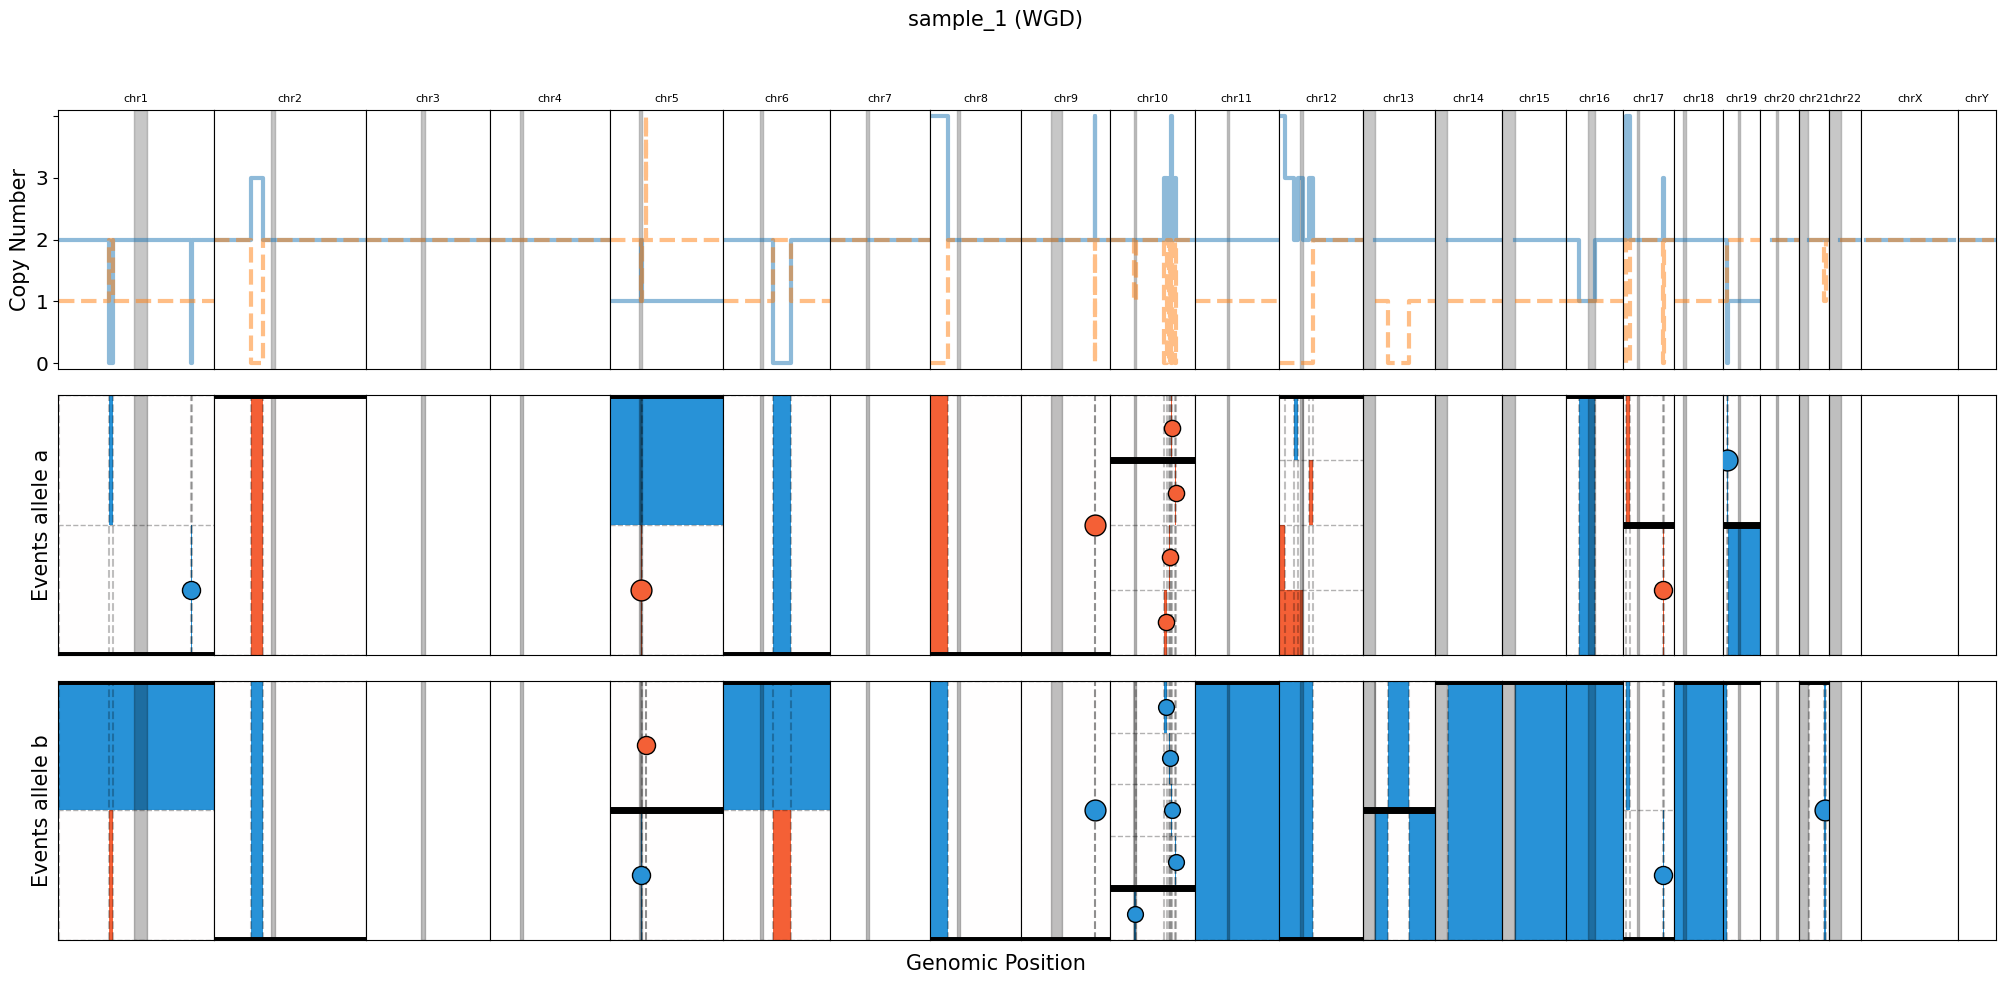

In [4]:
cur_sample = 'sample_1'

fig, axs = plot.plot_inferred_events_per_sample(
    cur_sample,
    chrom_segments,
    final_events_df,
    unit_size=False,
)

### Copy-number segments instead of genomic position

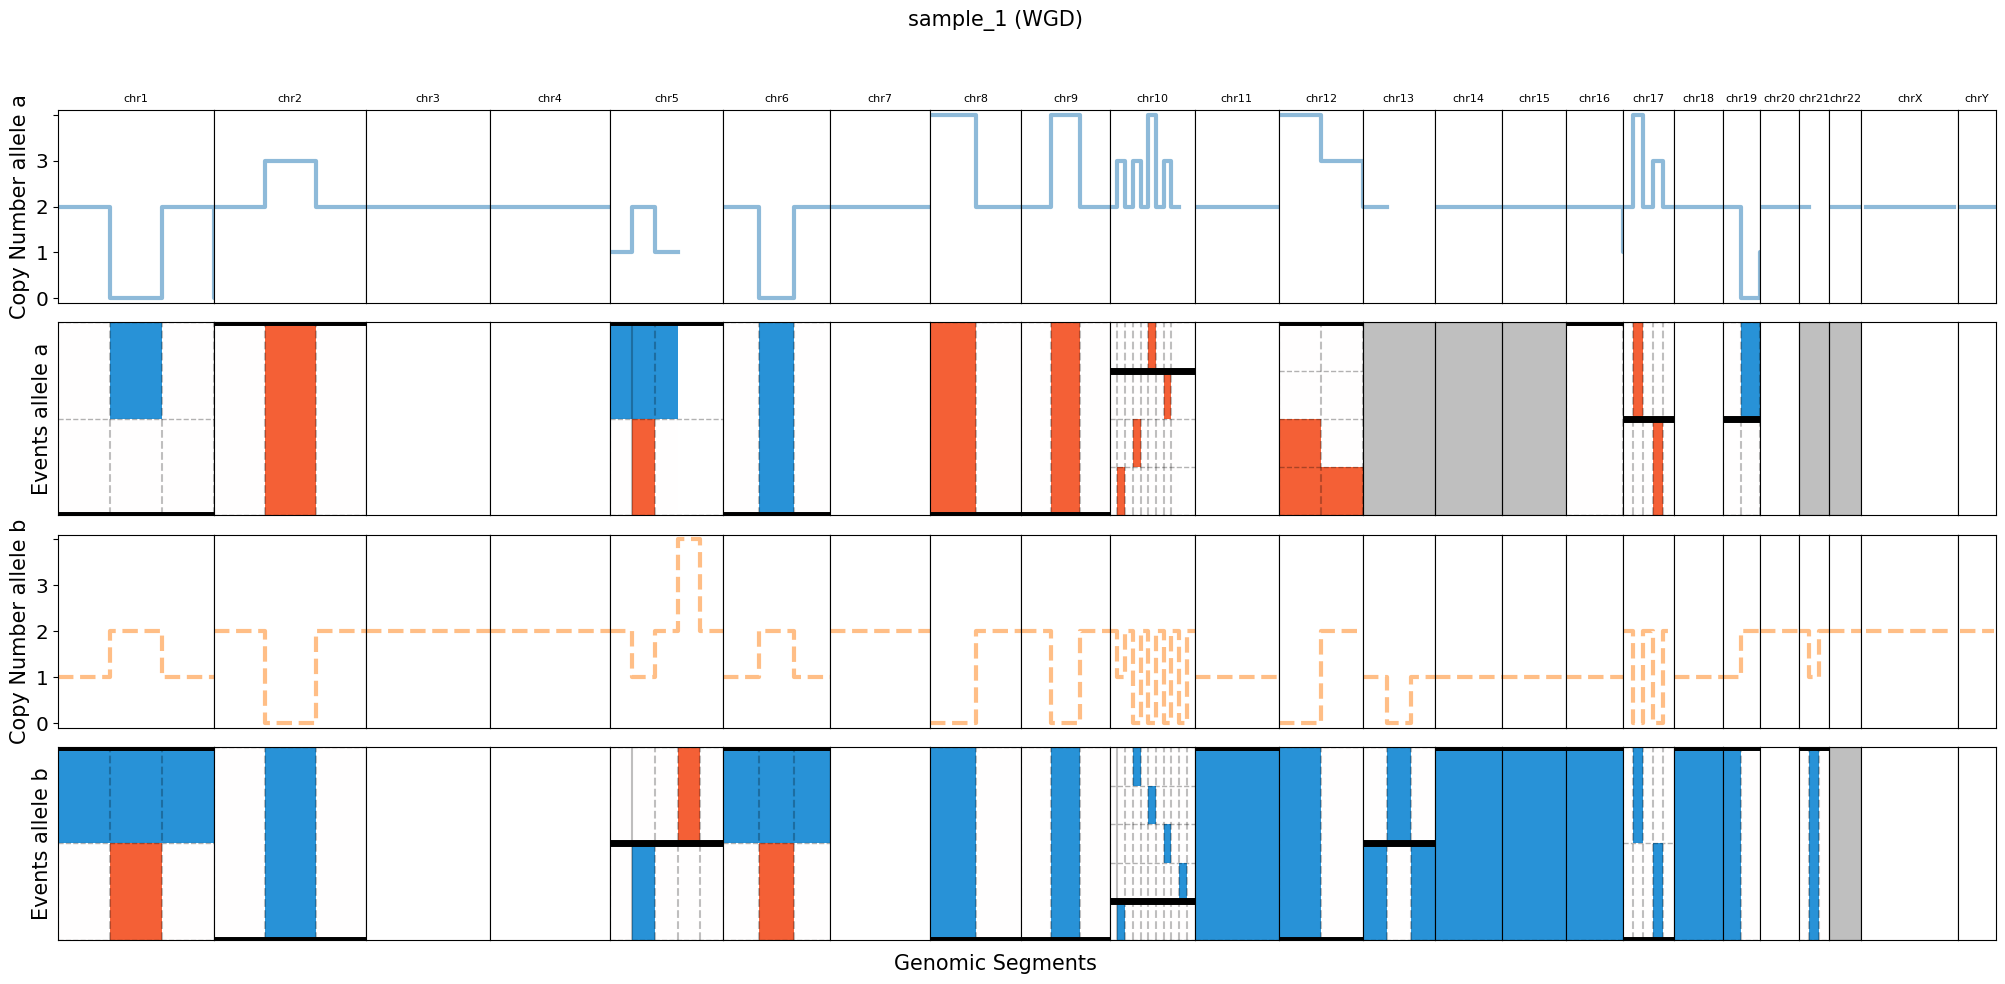

In [5]:
cur_sample = 'sample_1'

fig, axs = plot.plot_inferred_events_per_sample(
    cur_sample,
    chrom_segments,
    final_events_df,
    unit_size=True,
)

## Per ID

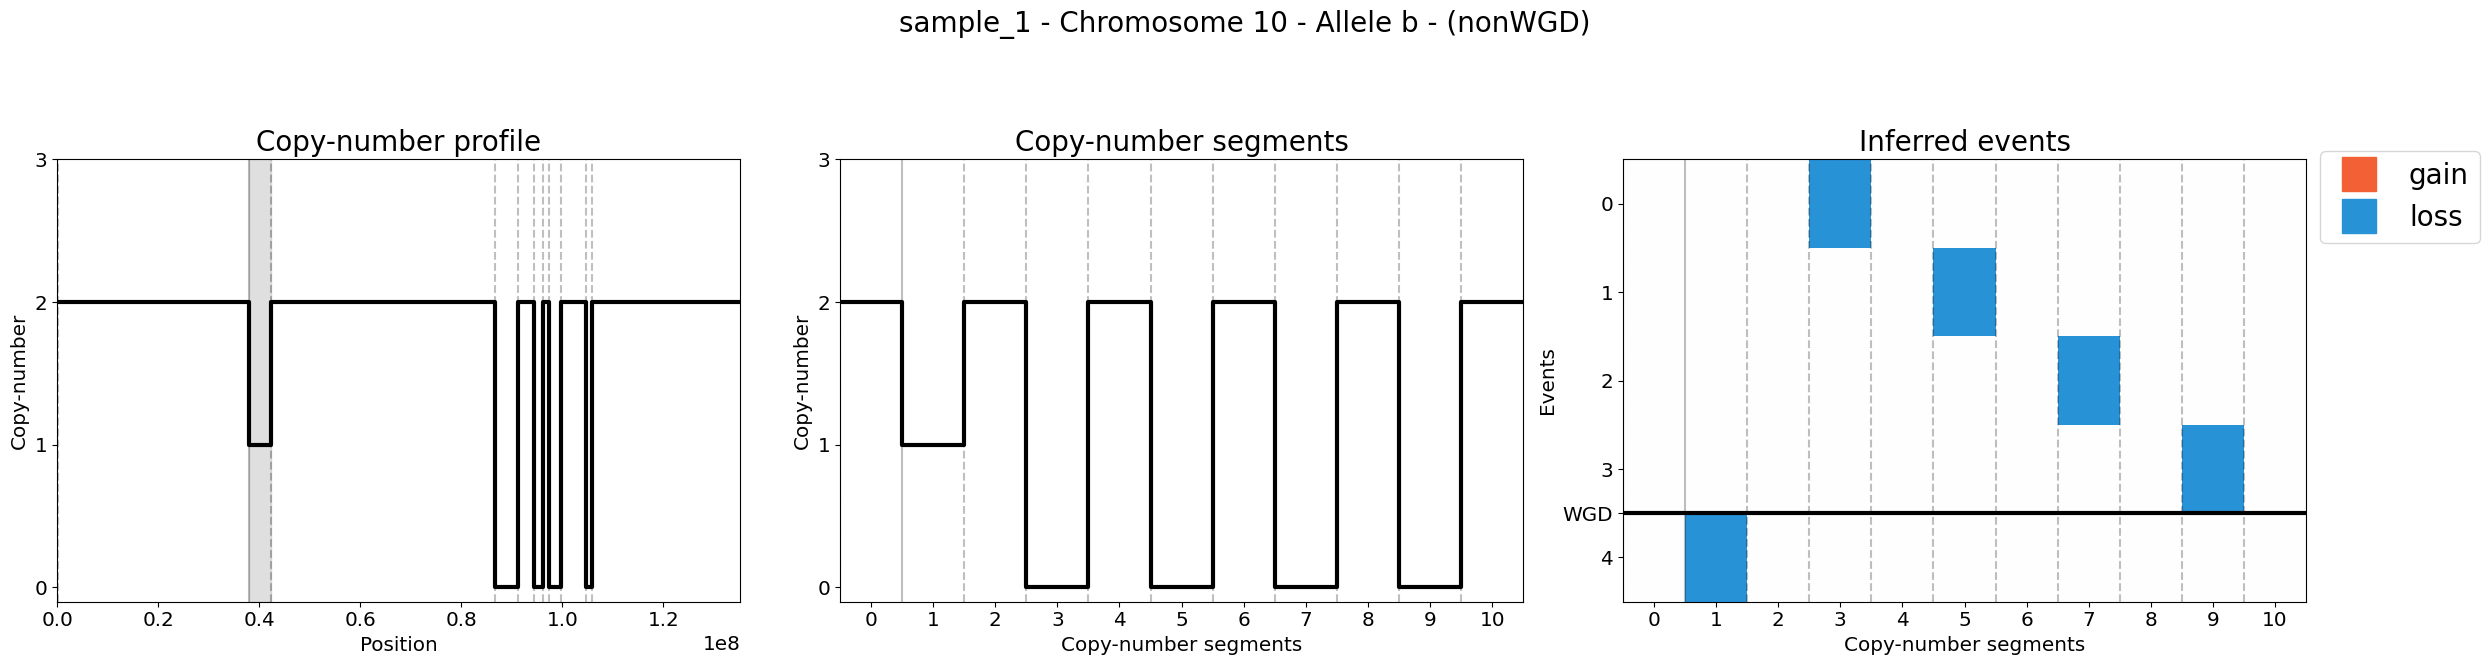

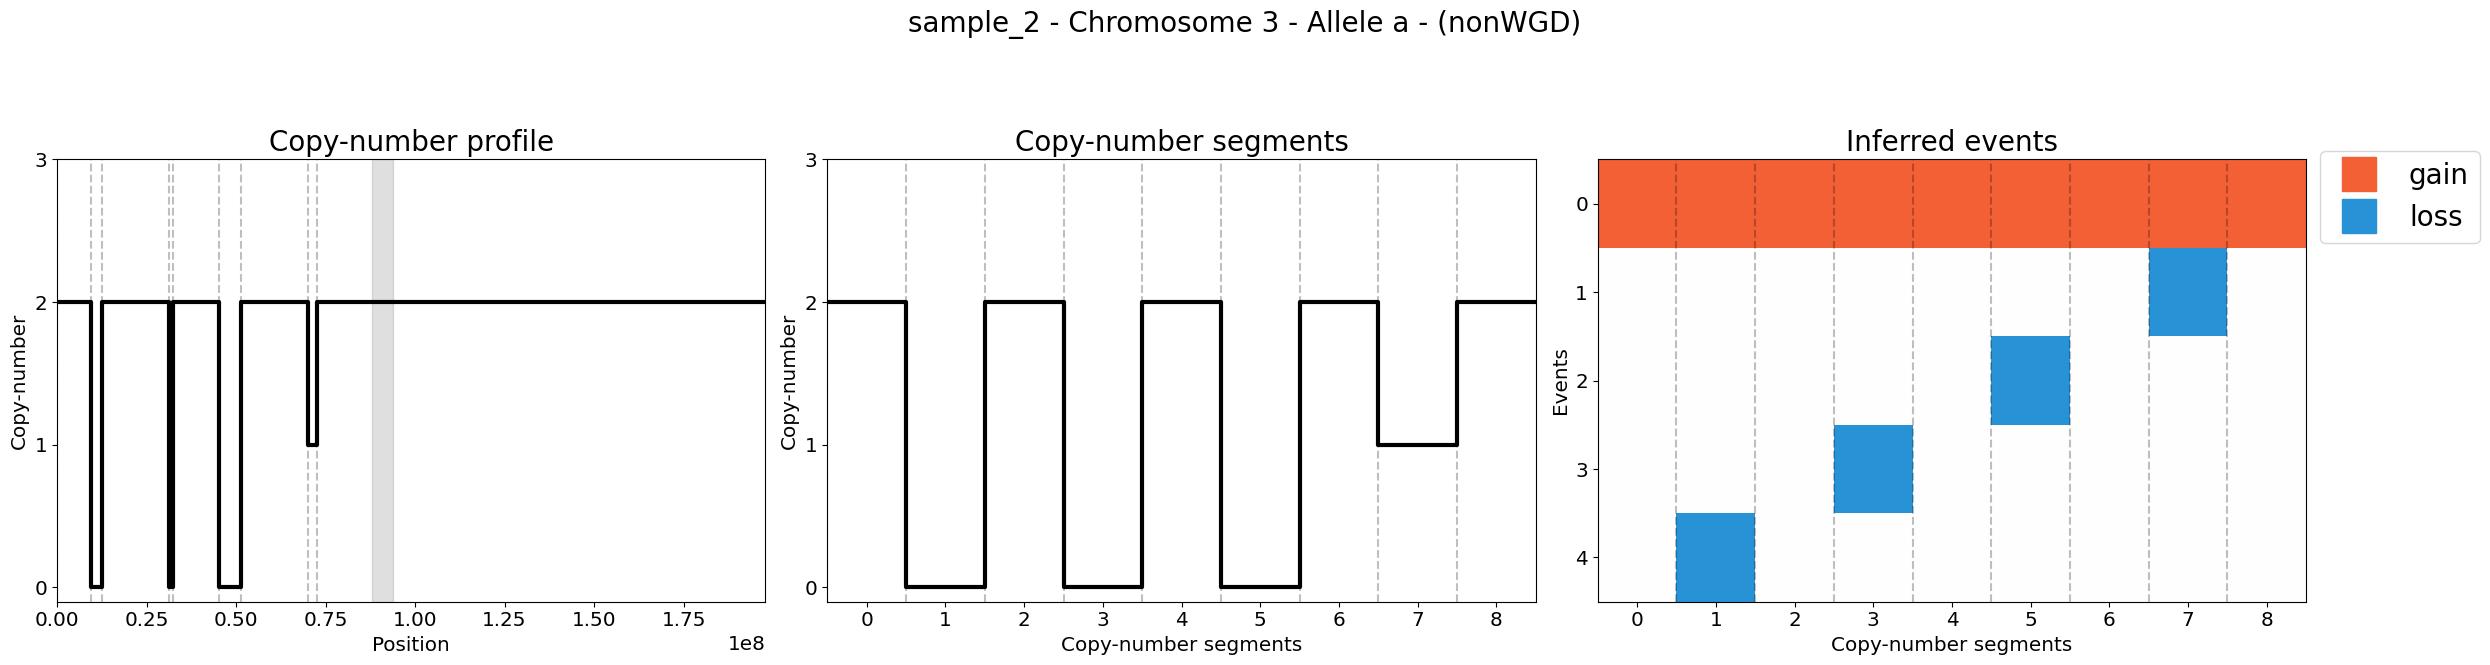

In [6]:
cur_ids = [
    'sample_1:chr10:cn_b',
    'sample_2:chr3:cn_a',
]
for i, cur_id in enumerate(cur_ids):   
    fig = plot.plot_inferred_events_per_id(
        cur_id, chrom_segments, final_events_df, single_row=True, show_legend=True,
        figsize=(25, 6), lw=3, markersize=4
    )
    plt.tight_layout()
    plt.show()

## Per ID with overlapping structural variants

In [7]:
sv_data = data_loaders.load_sv_data('../data/example_sv_data.tsv')

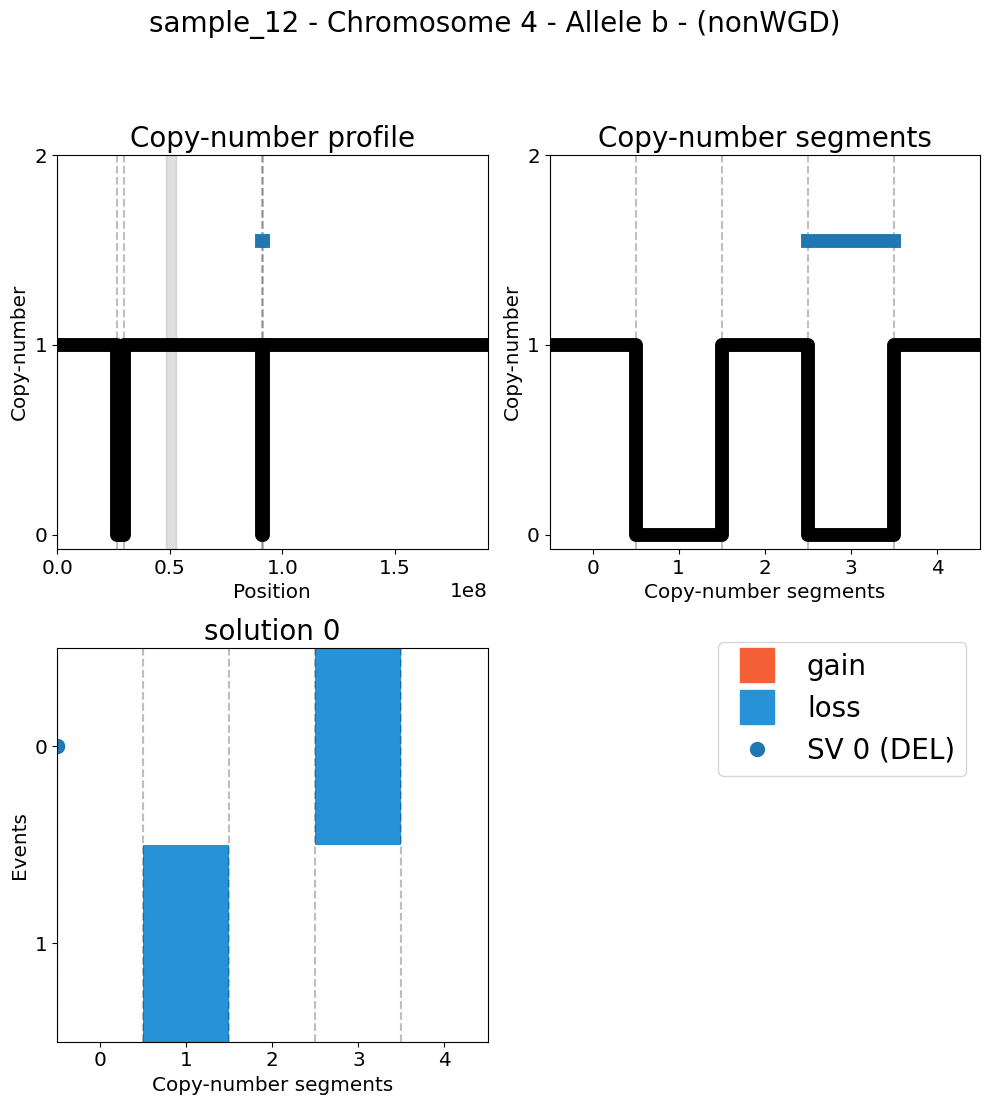

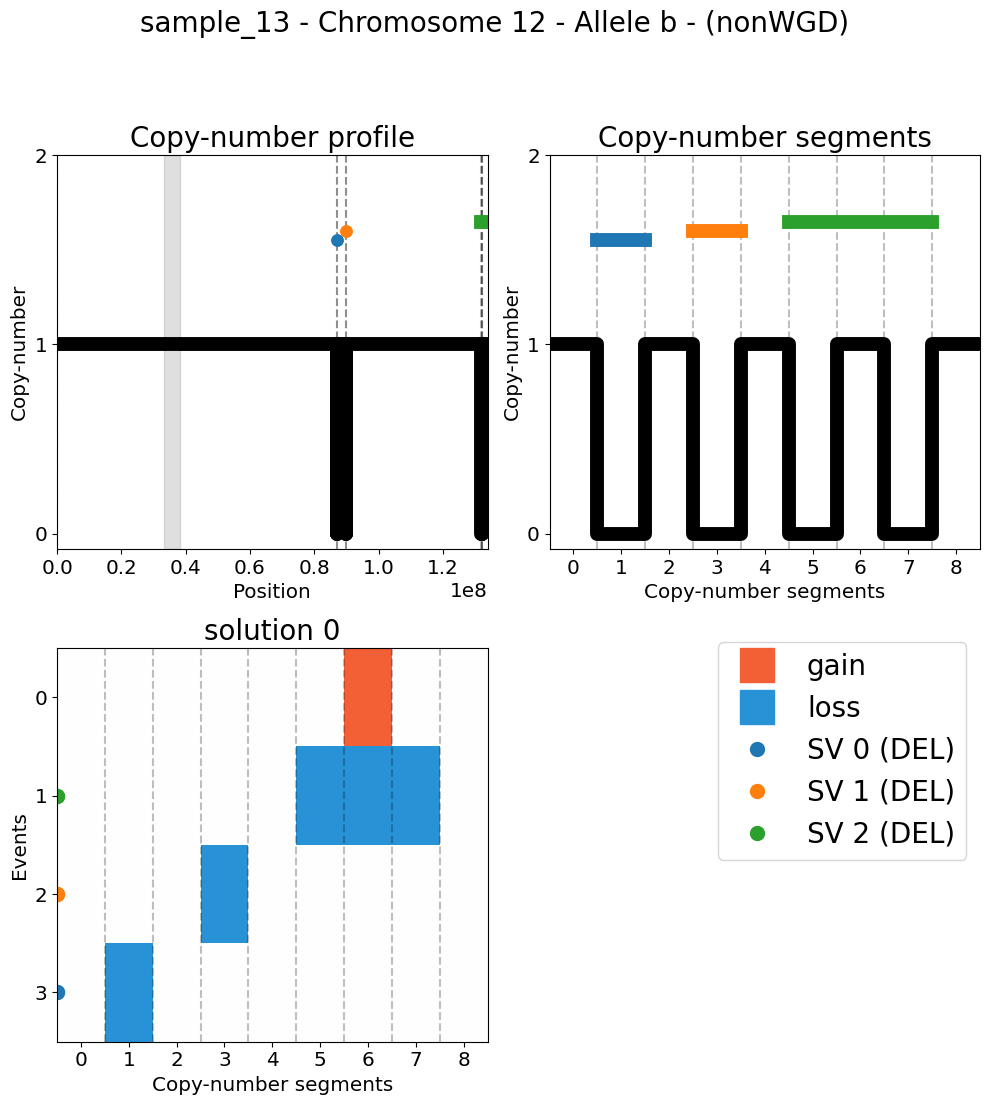

In [8]:
for cur_id in ['sample_12:chr4:cn_b', 'sample_13:chr12:cn_b']:
    fig = plot.plot_inferred_events_per_id(
        cur_id,
        chrom_segments,
        final_events_df,
        sv_data=sv_data
    )
    plt.show()

# Aggregated events

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

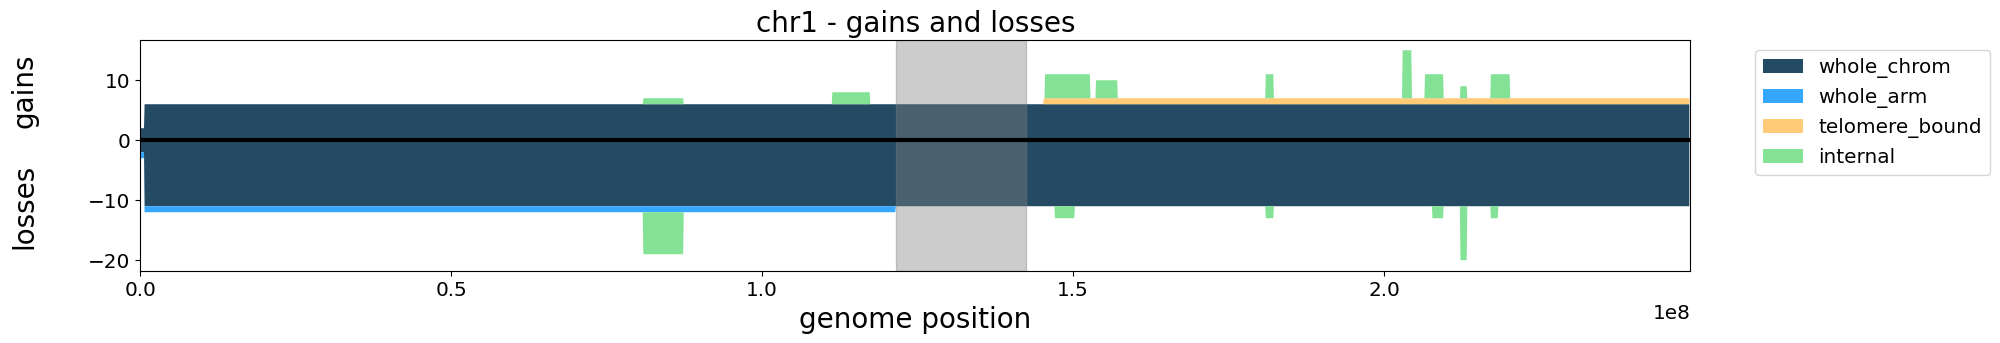

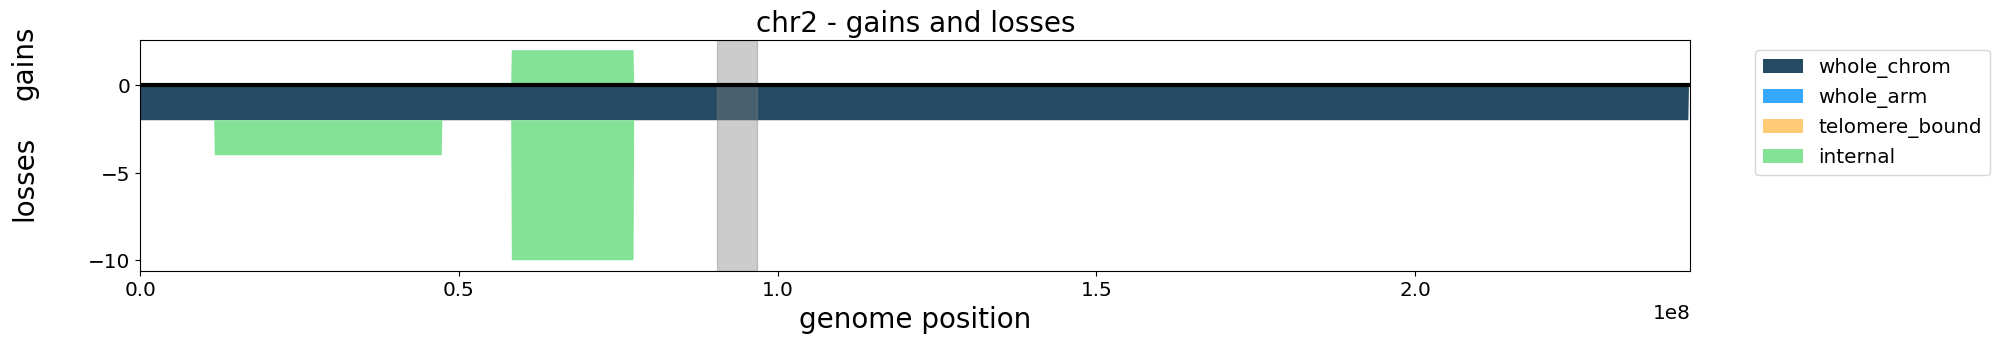

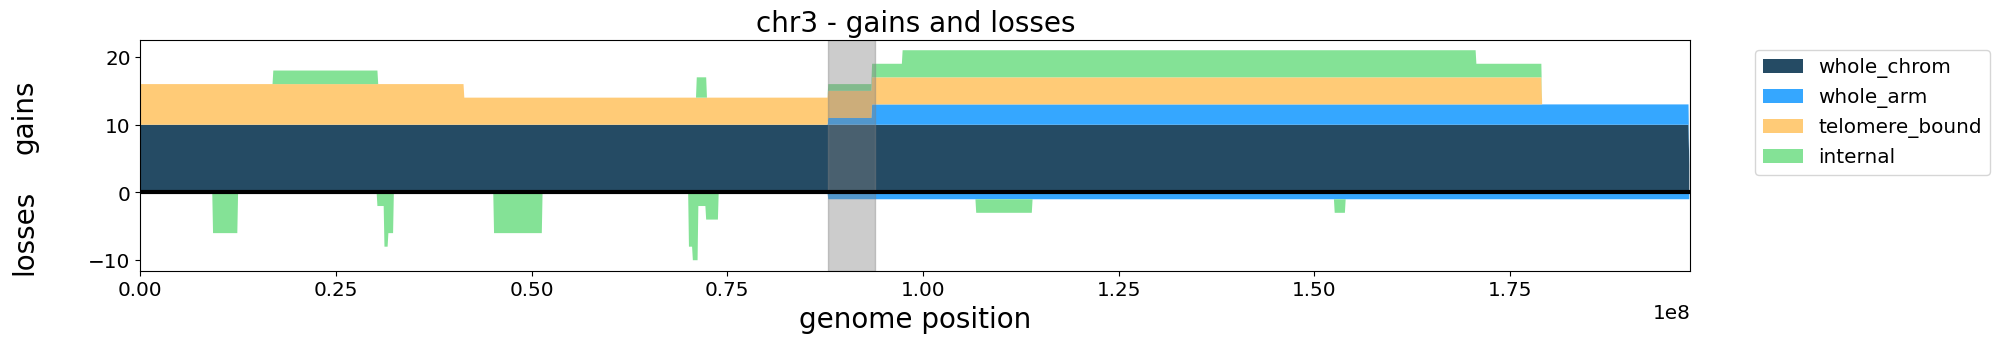

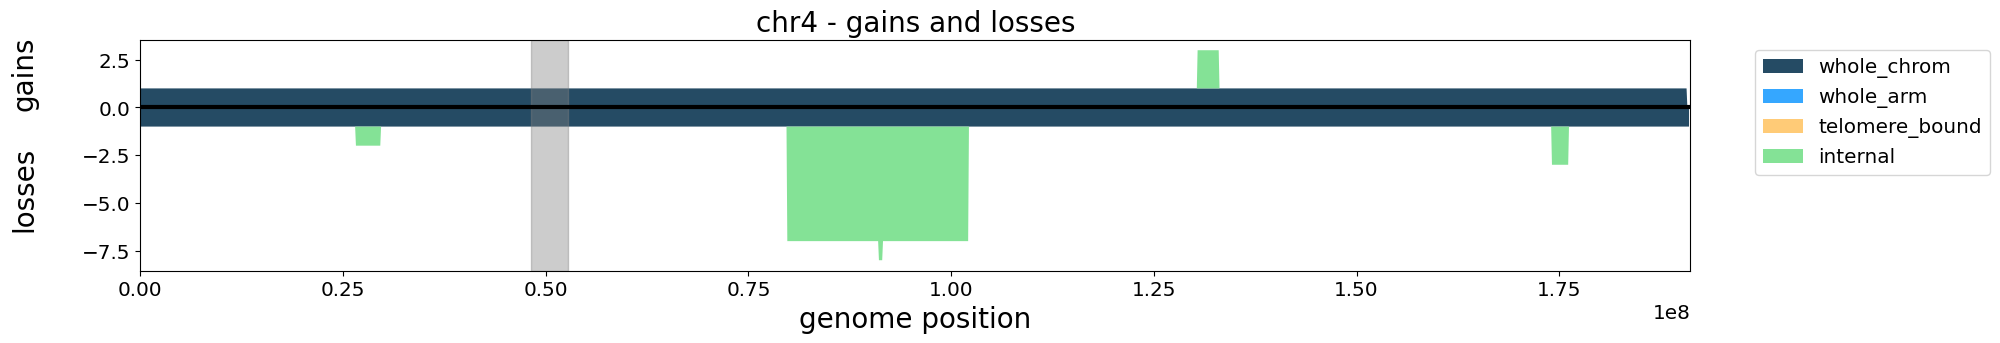

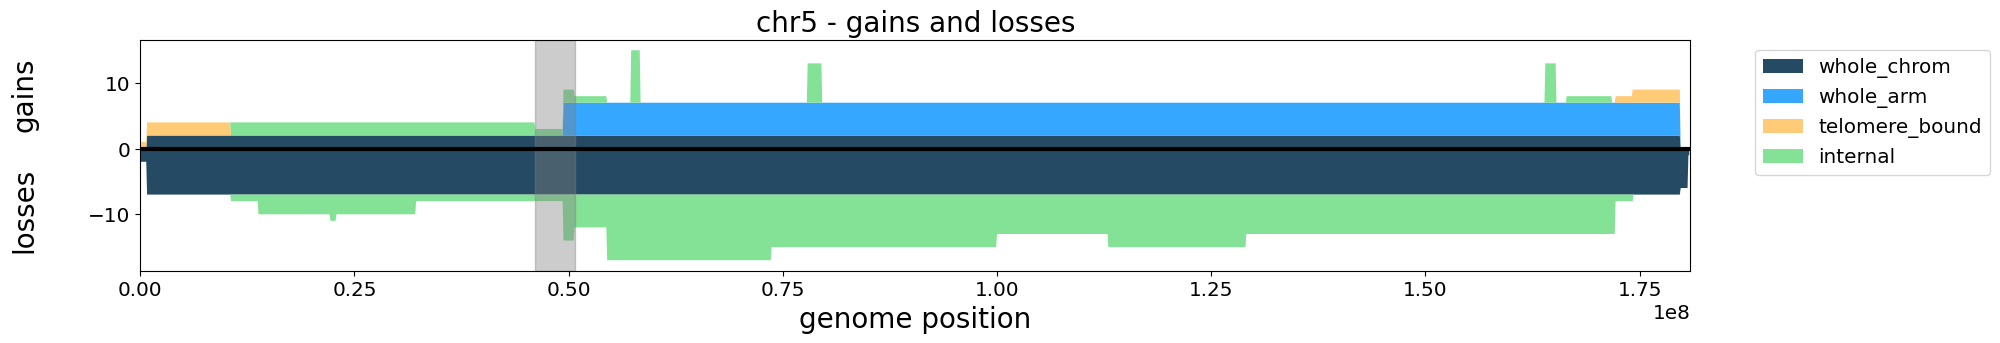

In [9]:
events_in_segmentation_100kbp = create_events_in_segmentation_full(final_events_df, segmentation=100e3)
for chrom in CHROMS[:5]:
    plot.plot_events_across_chromosome(chrom, cur_segmented_events=events_in_segmentation_100kbp,
                                       figsize=(20, 3));
    plt.show()